# GaugePredict Data Downloader
### Caitlin R. R. Turner, September 2025

This notebook builds basin-scale predictor datasets from USGS gauge records for use with the GaugePredict forecasting framework. It provides a reproducible workflow to:

- Specify a **target gauge** where discharge or stage will be predicted.
- Select **upstream predictor gauges** by Hydrologic Unit Code (HUC) region.
- Download daily time series from the USGS NWIS service `dataRetrieval` for all selected sites.
- Save site metadata and synchronized time series for direct use in model training and evaluation.

The outputs are structured to plug directly into downstream GaugePredict routines, including sequence generation, train–test splitting, and SHAP-based site selection.

### Import Necessary Dependencies

In [3]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import contextily as ctx
from dataretrieval import nwis
from GaugePredict.downloader import load_target, GaugebyHUC
from GaugePredict.plotting import plot_hucs, plot_statistics

from pathlib import Path

### Create File Directories 

In [4]:
nb_directory = Path.cwd()
project_root = nb_directory.parent
examples_dir = project_root / "Examples"

### Upload Shapefiles
Download the shapefiles for the basins you are interested in. Basin boundary shapefiles can be downloaded from the USGS National Hydrography dataset:  
[USGS National Hydrography Products](https://www.usgs.gov/national-hydrography/access-national-hydrography-products)

For this example, we will load all Hydrologic Unit Code (HUC) zones covering the Continental United States (CONUS). 

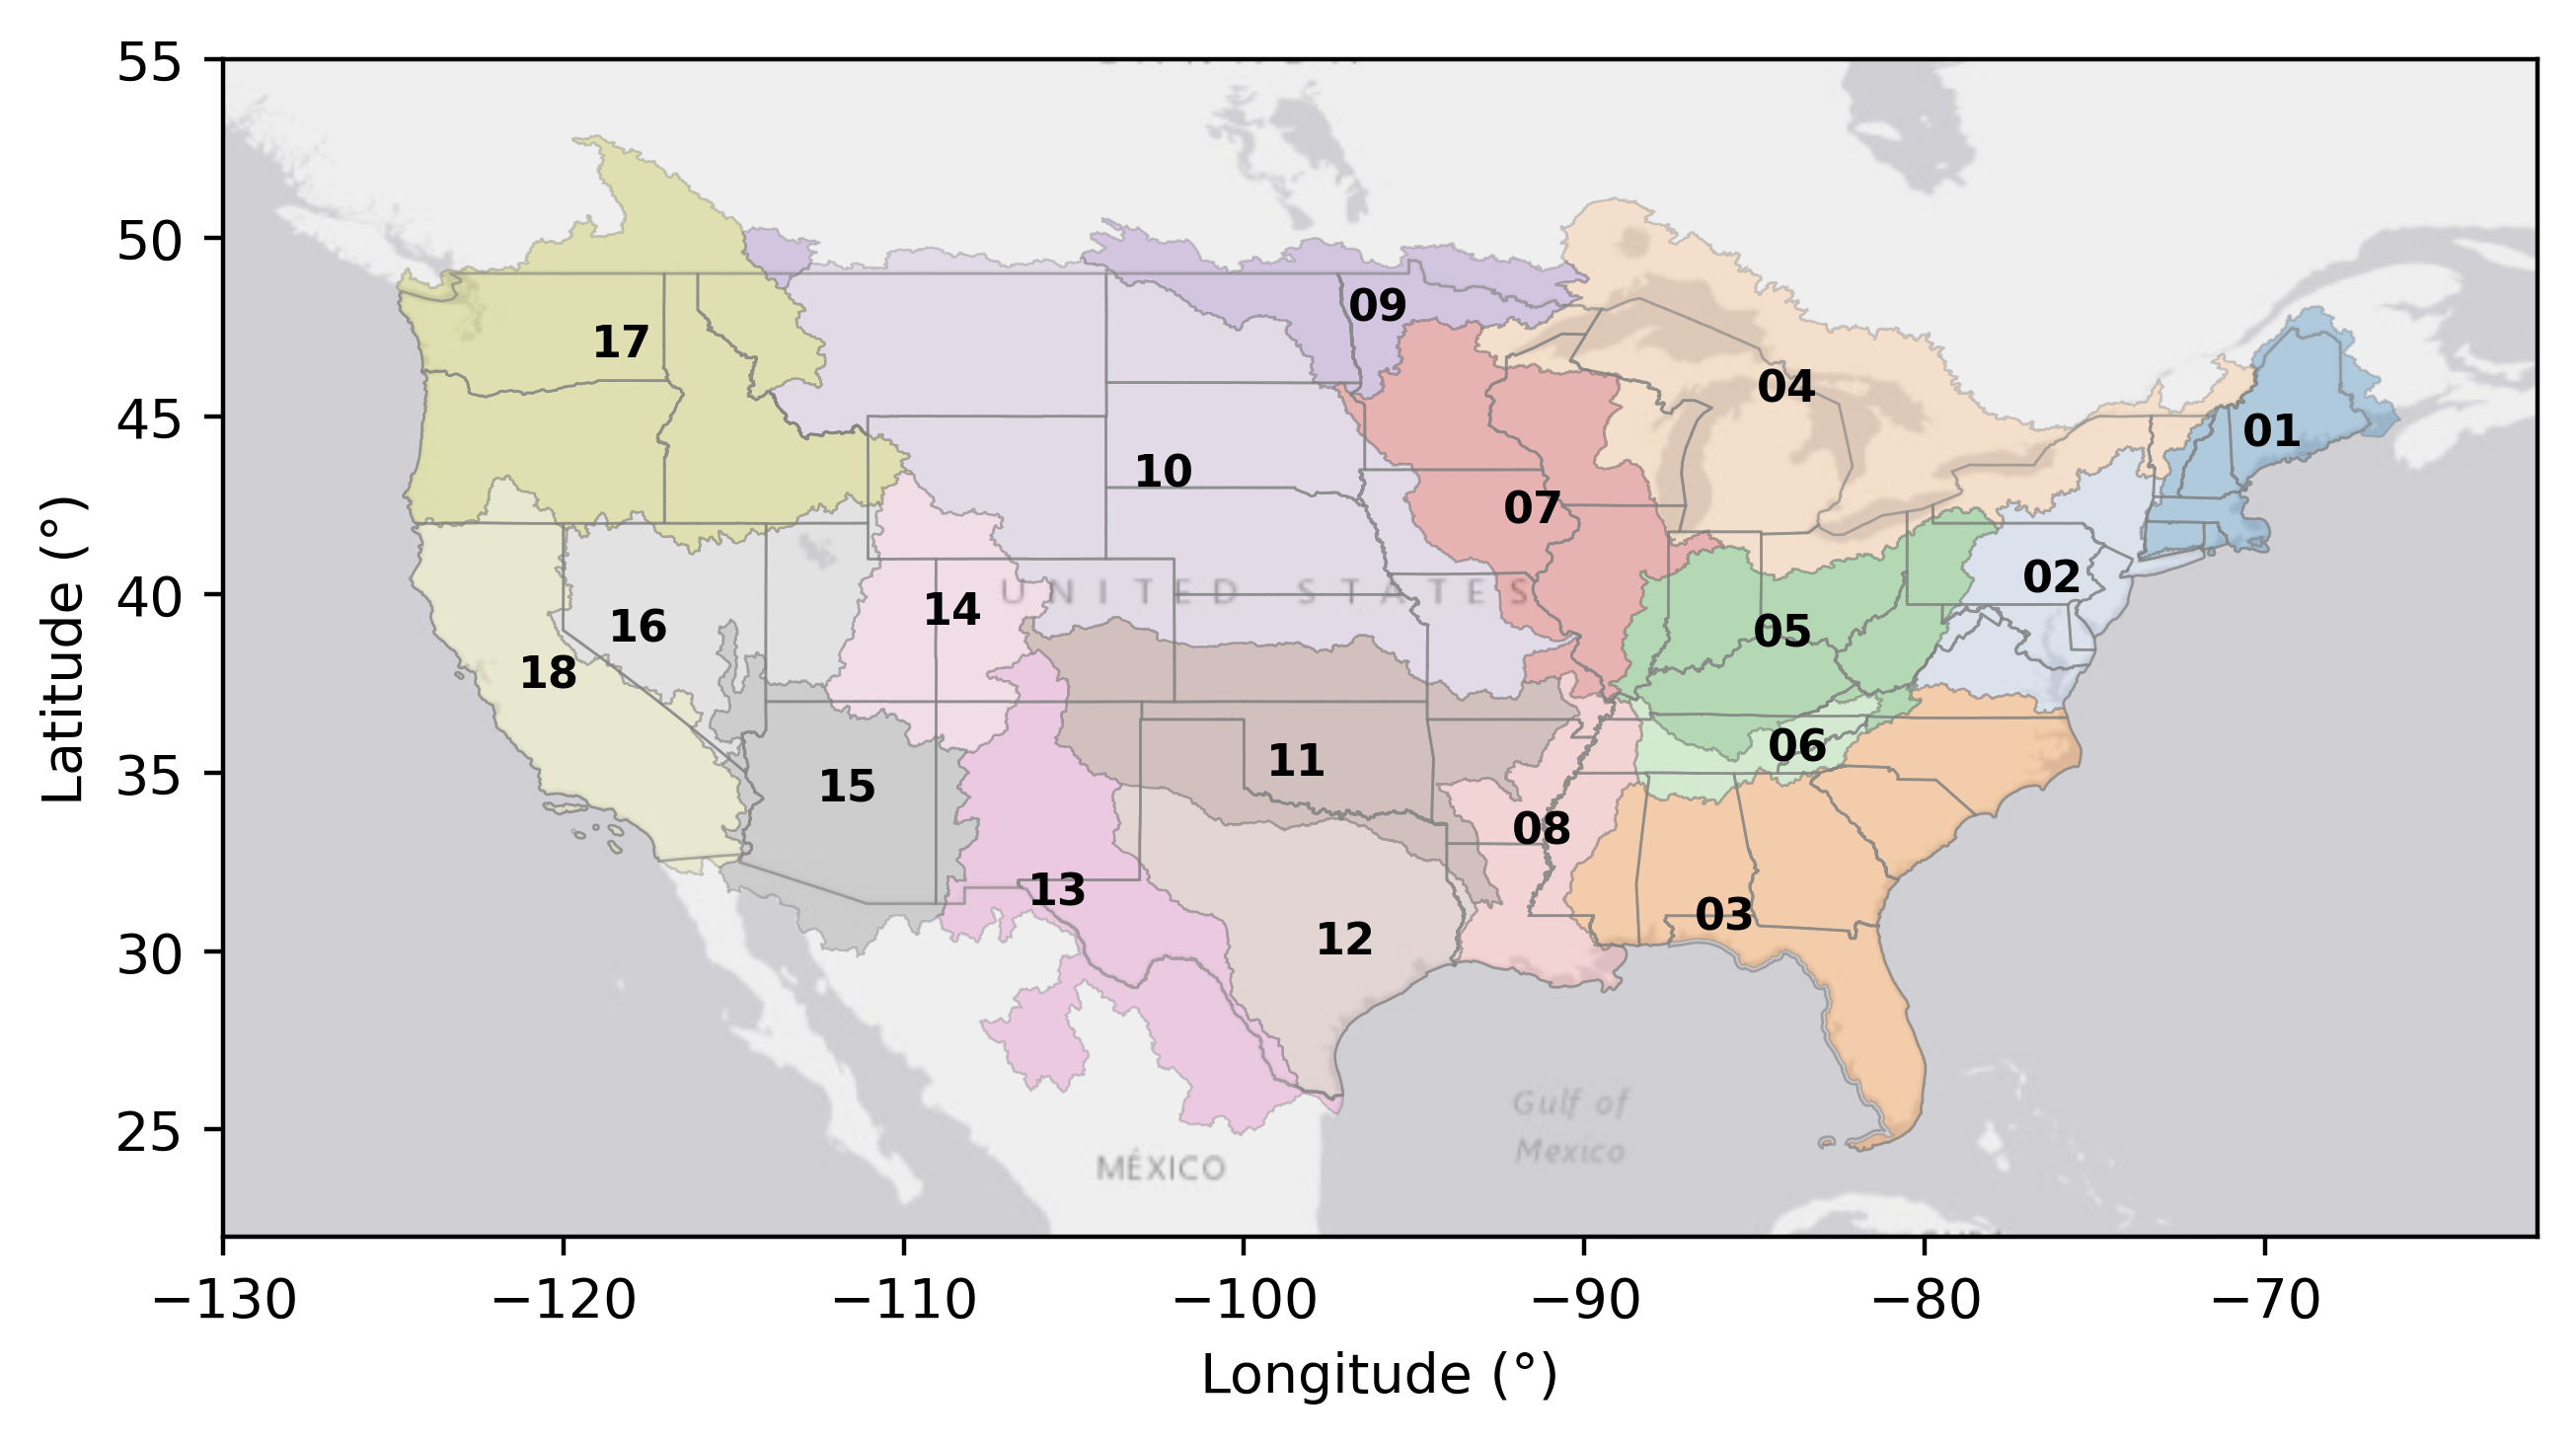

In [5]:
fig, ax = plot_hucs(
    base_dir="shapefiles/HUC_Zones", # USGS HUC Codes
    states_fp="shapefiles/US_STATES/tl_2023_us_state.shp", # US State Boundaries
    include_ak=False,
    basemap=True)


### Determine HUC Zones

For this step, we focus on the Hydrologic Unit Code (HUC) zones that fall within the Mississippi River Basin (MSRB).  

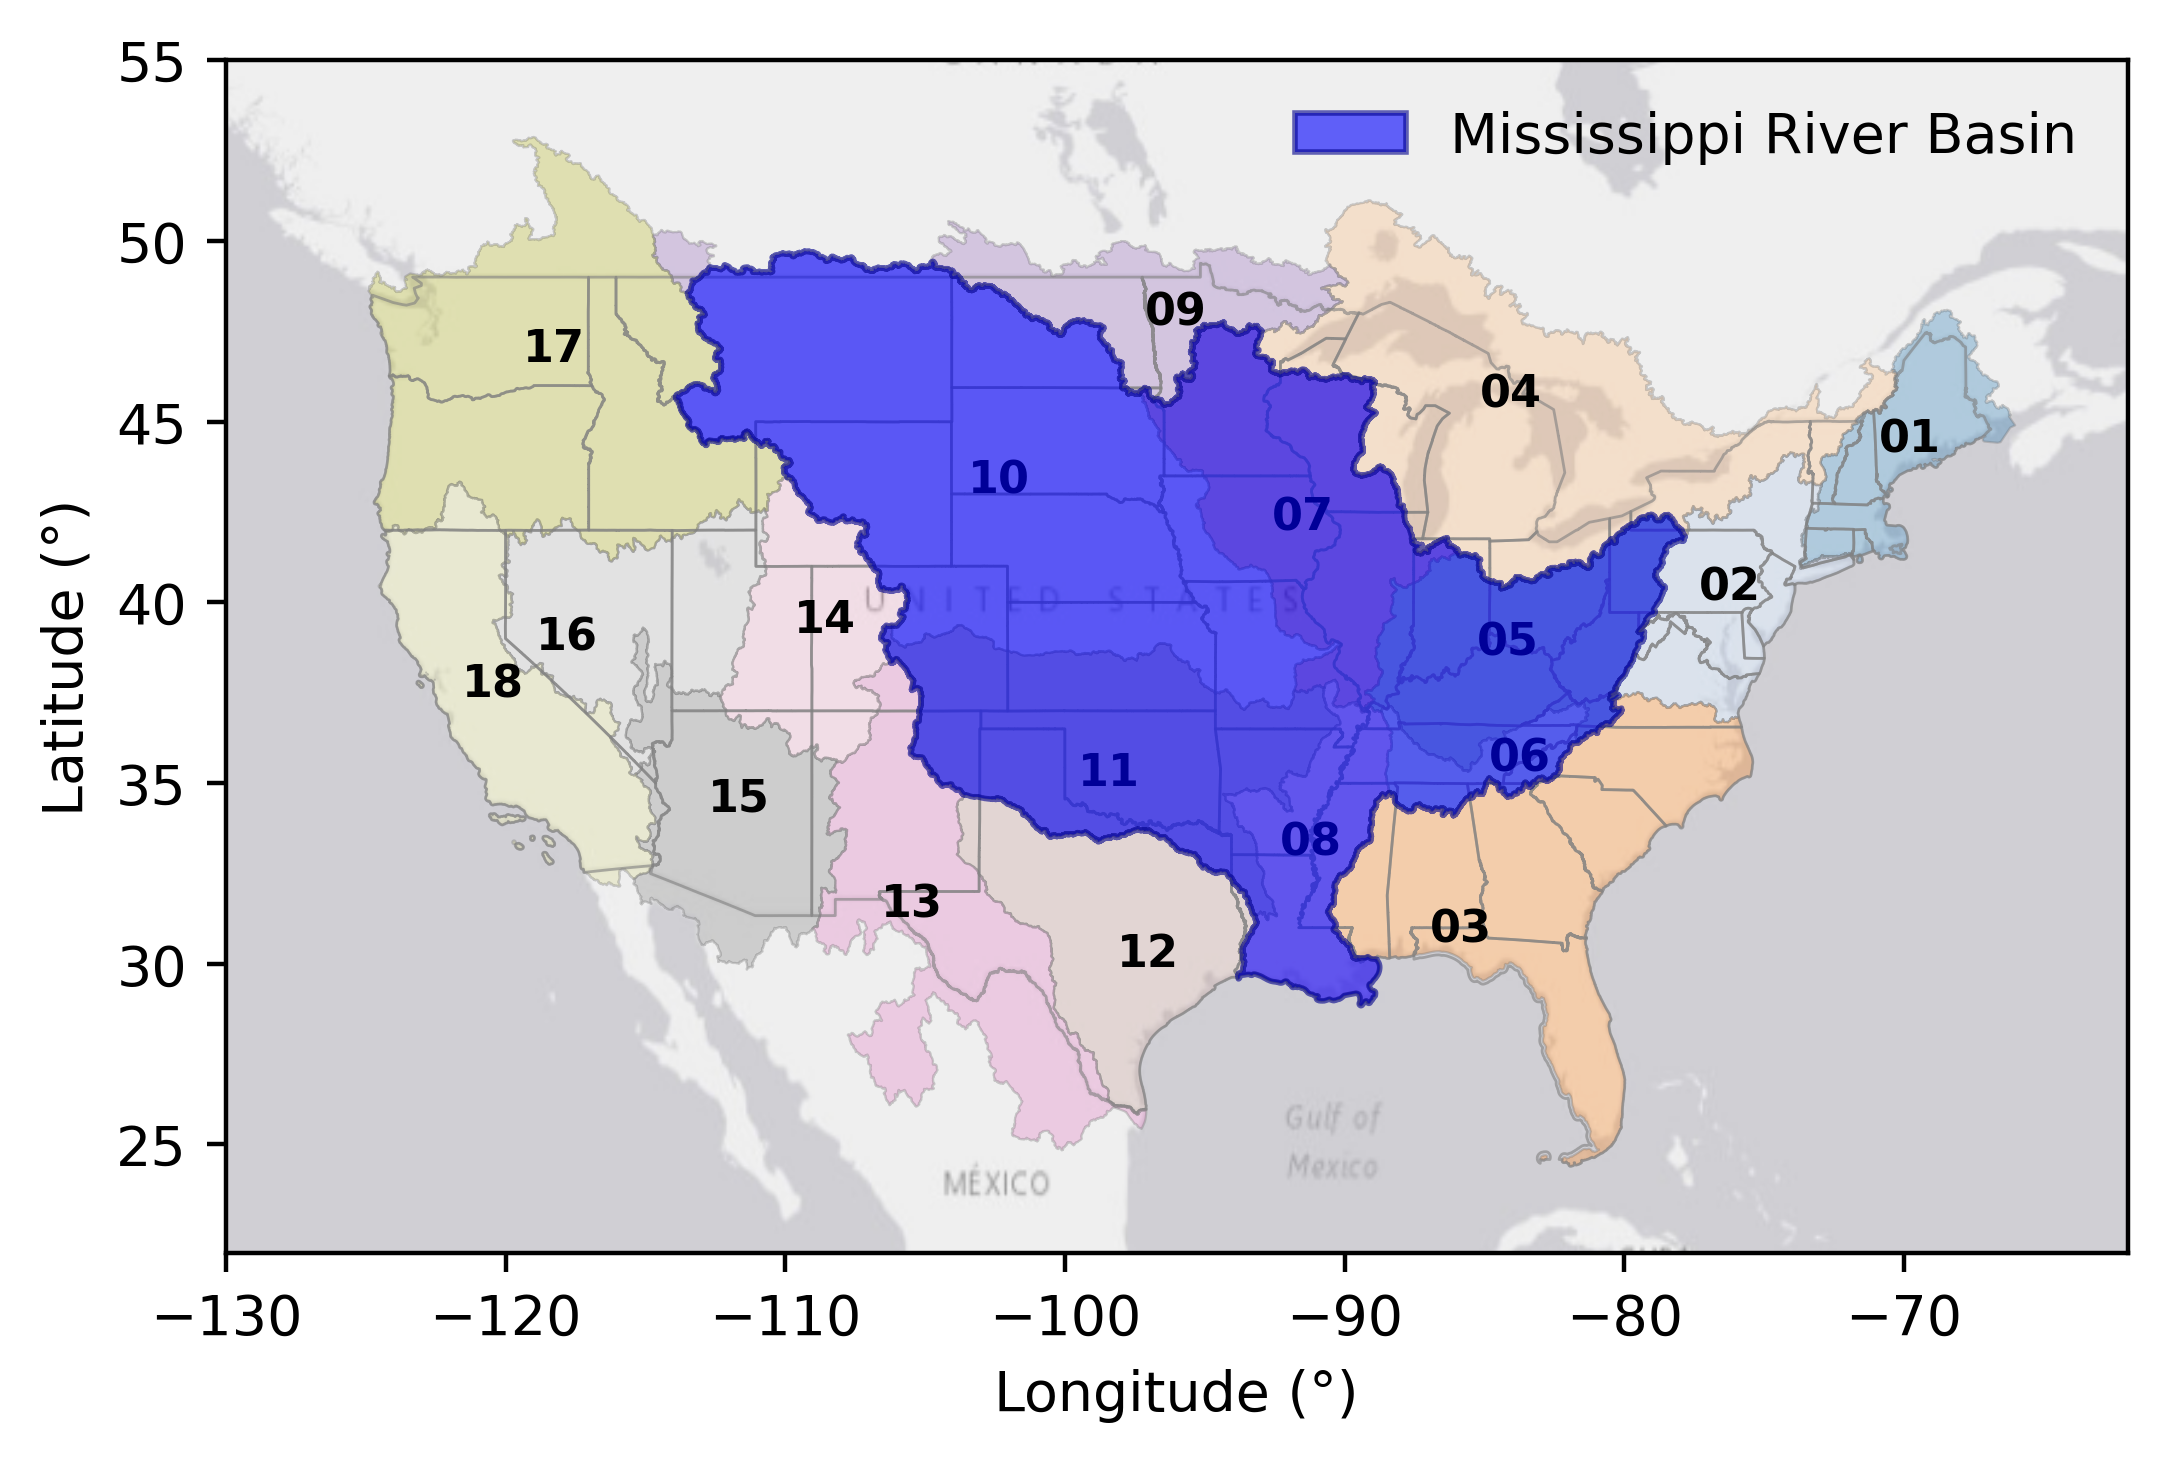

In [6]:
# your plotting
fig, ax = plot_hucs(
    base_dir="shapefiles/HUC_Zones",
    states_fp="shapefiles/US_STATES/tl_2023_us_state.shp",
    include_ak=False,  
    basemap=True)

target_epsg = 4326  # This changes the epsg to the same datum

basin = gpd.read_file("shapefiles/MSRB/Miss_RiverBasin.shp") # Mississippi River Basin boundaries
basin = basin.to_crs(target_epsg)

basin.plot(ax=ax,
           facecolor='blue',
           edgecolor="darkblue",
           alpha=0.6,
           zorder=4)

legend = ax.legend(handles=[mpatches.Patch(facecolor='blue',
                            edgecolor="darkblue",
                            alpha=0.6,
                            label="Mississippi River Basin")],
                            frameon=False, 
                            fontsize=10)


### Name HUC Zones

We can see that the HUC zones 05, 06, 07, 08, 10, and 11 fall within the Mississippi River Basin (MSRB).  We will also include HUC zone 09 because of its proximity to the basin. Discharge in the Mississippi River is strongly influenced by snowmelt, so including this adjacent zone helps capture upstream contributions.

In [7]:
huc_codes = ["05", "06", "07", "08", "09", "10", "11"]

## Downloading Discharge at a Target Site

We begin by selecting a target gauge. For this example, the target site is **Baton Rouge**
(USGS site `07374000`).

Discharge data are downloaded using the GaugePredict downloader utilities, which provide a
consistent interface to the USGS NWIS service and apply the same formatting and unit conversions
used throughout the GaugePredict workflow. The **start** and **end dates** define the analysis
period and are chosen to match the available record at the target site.

The resulting time series is indexed at daily resolution and is checked for missing dates so that
a continuous sequence can be constructed for subsequent model input generation.

### Target site configuration

The following variables define the target site and download settings:

- `parameter`: hydrologic variable to download (here, discharge)  
- `parameter_code`: USGS parameter code (`00060` = discharge)  
- `target_site`: USGS gauge ID for the prediction location  
- `start_date`, `end_date`: date range for the analysis period

  
Downloaded values can be returned in either:
- `metric` (m³/s, meters, etc.)
- `customary` (ft³/s, feet, etc.)

In [13]:
parameter = "discharge"
parameter_code = "00060"
target_site = "07374000"
start_date, end_date = "2005-01-02", "2024-12-31"
units = "metric"

### Time index for the analysis period

Before downloading any data, we define the time grid that will be used throughout the workflow.
This ensures that all downloaded time series can later be aligned to the same daily timeline.

A complete daily index, `full_index`, is created using the previously defined `start_date` and
`end_date`. This index contains every calendar day in the analysis period and will be used to
reindex all target and predictor time series after download.

#### Time index variables

The following variables define the analysis time grid:

- `full_index`: continuous daily datetime index from `start_date` to `end_date`  
- `freq="D"`: sets the index spacing to daily intervals  
- `tz="UTC"`: assigns a consistent time zone and avoids daylight saving time shifts  

This standardized time index will be applied to all datasets to ensure consistent sequence
generation and model input alignment.


In [16]:
full_index = pd.date_range(start=start_date, end=end_date, freq="D", tz="UTC")

### Download target site data function
The `load_target` function wraps the NWIS request and returns a daily, time-indexed
DataFrame formatted for direct use in GaugePredict workflows.

In [19]:
target_df = load_target(
    target_site=target_site,
    full_index=full_index,
    parameter_code=parameter_code,
    start_date=start_date,
    end_date=end_date,
    to_units=units)

### Creating a Continuous Daily Time Index

The downloaded gauge record may contain missing days. To prepare the data for sequence-based
models, the time series is reindexed to a continuous daily grid spanning the full analysis
period.

The modeling target, `target`, is reindexed to `full_index` and missing values are filled so
that the final series contains no gaps and can be used directly as model output.

- `target`: one-dimensional pandas Series of daily discharge values at the target gauge, with no
  missing dates and indexed by `full_index`  

This standardized daily target series is used for all subsequent sequence generation, training,
and evaluation steps.

In [21]:
target = (target_df.reindex(full_index).interpolate(limit_direction="both").ffill().bfill())

## Statistics for the Target Site
Basic summary statistics and exceedance behavior are useful for understanding the range and
variability of discharge at a target gauge. For this example, statistics are computed for the
Baton Rouge site using the processed daily target series.

The plotting function generates time series summaries and highlights values above a specified
critical threshold, which can be used to indicate flood-relevant conditions or operational
interest levels.

### Statistics and plotting variables
The following variables define the statistics plot:

- `target`: daily discharge time series at the target gauge, with a continuous daily index  
- `critical_threshold`: threshold used to flag high-flow conditions (35,400 m³ s⁻¹ for discharge at Baton Rouge)  
- `ylim`: y-axis limits (ex. discharge plot (m³ s⁻¹))  

The function returns a Matplotlib figure and axis handles for further customization if needed.

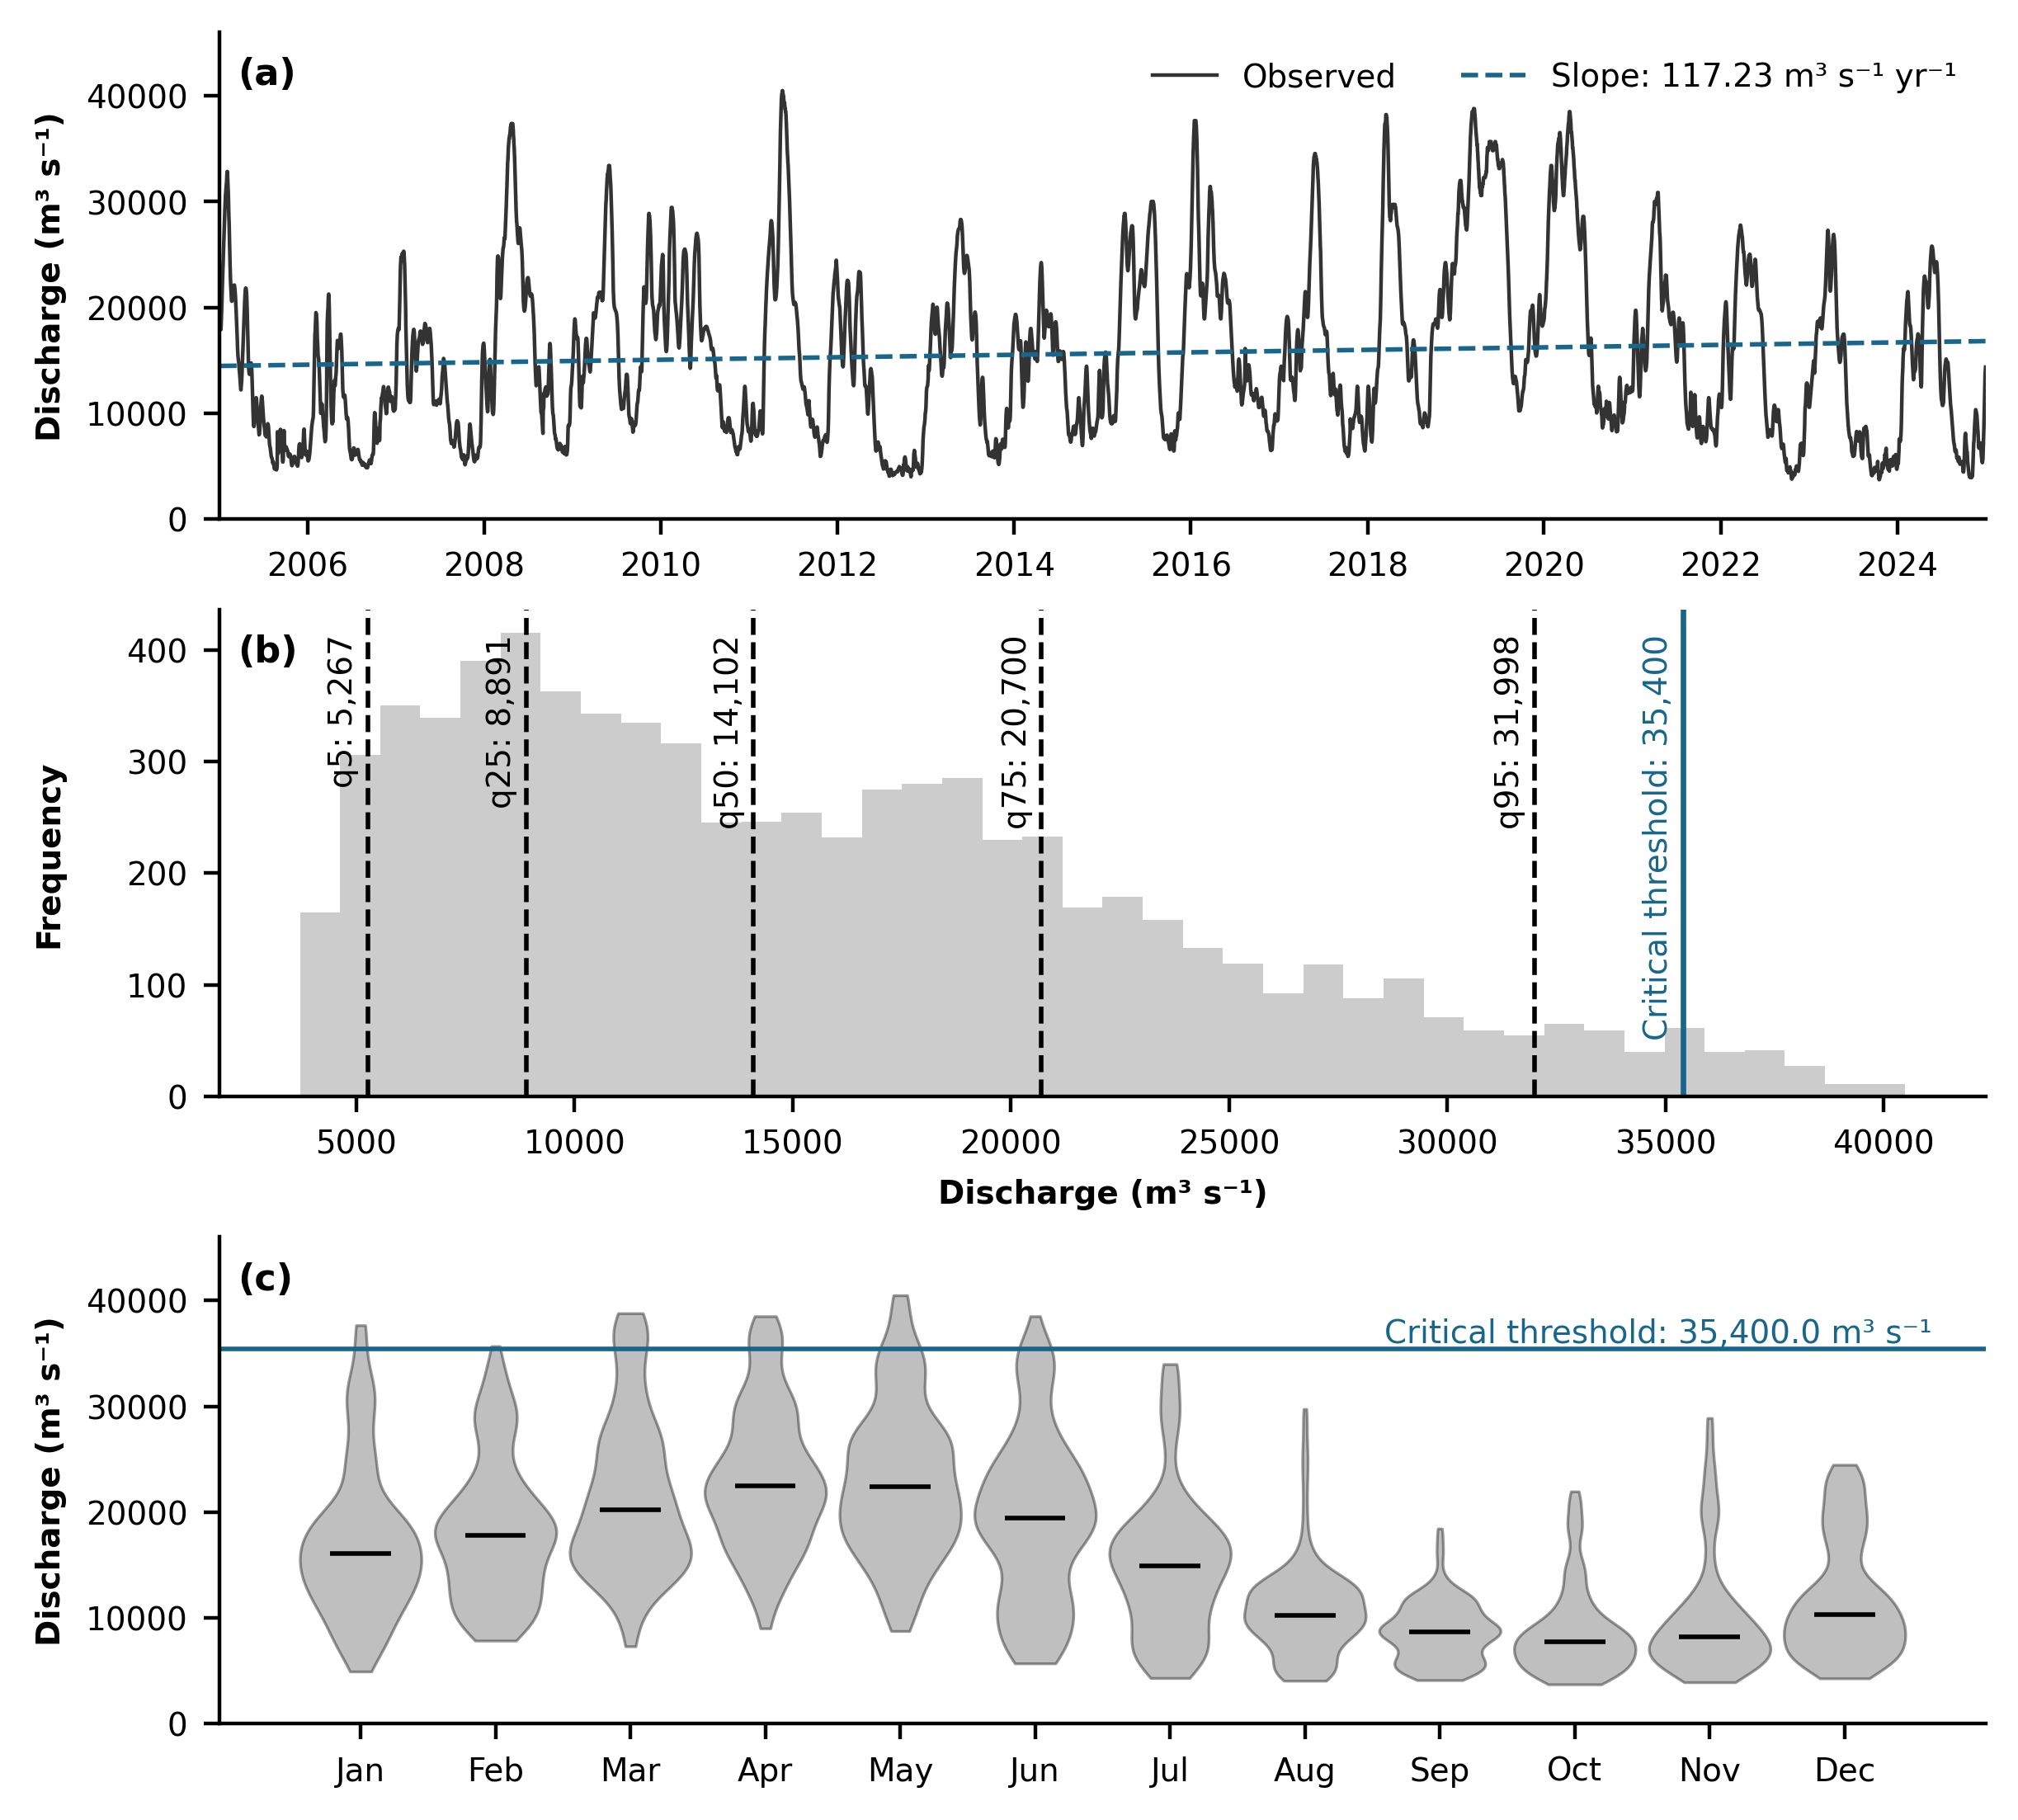

In [22]:
fig, axes = plot_statistics(target, critical_threshold=35400.0, ylim=(0, 46000))

## Download Predictor Sites by HUC

First, set the file path where predictor site data will be downloaded and stored.  
If data has already been collected, this path can also be used to upload and access existing files.  

We also define where to save the outputs. The time-series data for each site will be written to `data_dir/`, and a site-metadata index will be saved to `json_path`.


In [ ]:
data_dir = Path(f"cached_data_{parameter}")
json_path = data_dir / f"site_dict_{parameter}.json"

We will build a predictor dataset from USGS gauges within the selected HUC zones. The goal is high coverage, so we filter sites using a `percent_threshold`. Here we set `percent_threshold = 95`, which keeps only sites whose daily record is at least 95% complete between `start_date` and `end_date`.

**Inputs**
- `start_date`, `end_date`: analysis window used both for data searching and completeness check.  
- `huc_codes`: list of HUC identifiers to search (e.g., `["07", "08"]`).  
- `parameter_code`: USGS parameter code (discharge is `00060`).  
- `percent_threshold`: minimum % of non-missing daily values per site in the window.  
- `siteType` (optional): USGS site type filter; use `'ST'` for streams, or set to `None`/omit to include all types.  
- `to_units`: unit system for output (`"metric"` or `"customary"`). Conversion is applied after download.

**Process**
1. Search sites in each HUC that report `parameter_code`.  
2. For each site, pull daily values over `[start_date, end_date]`.  
3. Check completeness; sites have data within the `percent_threshold`.  
4. Write daily series to `data_dir/` and a JSON site index to `json_path` with metadata (site number, name, HUC, period, completeness).  
5. Return a `summary` with counts.

**Outputs**
- Time-series files for each retained site in `data_dir/`.  
- `json_path`: dictionary of retained sites and their metadata.  
- `summary`: totals (sites found/kept), and pointers to outputs.

We will use these predictors to model discharge at the target site using the selected HUC zones. If you need other constituents, consult the USGS parameter catalog (e.g., discharge `00060`).

> Note: downloading from many sites can be slow because the code queries NWIS for each site. Data should only need to be downloaded the first time. A copy of this dataset can be found on HydroShare.

In [ ]:
percent_threshold = 95
to_units = "metric"           # or "customary"
parameter_code = "00060"      # USGS discharge (daily mean) parameter code

# Optional: restrict to streams only ('ST'); set to None or omit to include all site types
siteType = "ST"

summary = GaugebyHUC(
    start_date=start_date,
    end_date=end_date,
    huc_codes=huc_codes,
    parameter_code=parameter_code,
    percent_threshold=percent_threshold,
    data_dir=data_dir,
    json_path=json_path,
    siteType=siteType)

If you have any questions or need help with implementation to your model, please do not hesitate to contact Caitlin R. R. Turner at cturn65@lsu.edu 


#### **Acknowledgments:**
Research reported in this publication was supported by the US Department of Defense/Army Engineer Research and Development Center (ERDC) under Contract No. W912HZ2220005, the Gulf Research Program of the National Academies of Sciences, Engineering, and Medicine under award number SCON-10000883, and the NSF through Open Earthscape (Collaborative Research: Frameworks: OpenEarthscape - Transformative Cyberinfrastructure for Modeling and Simulation in the Earth-Surface Science Communities) award No. 2104102.